# Part A - Exploratory Data Analysis

## Amsterdam Airbnb Data Engineering & Analytics Challenge

This notebook performs focused EDA using the validated DuckDB warehouse:

`data/warehouse/airbnb_analytics.duckdb`

### Questions answered
1. Which neighbourhoods have the most listings?
2. Which neighbourhoods have the highest median prices?
3. How do room types differ?
4. How do host portfolio segments differ?
5. Which neighbourhoods show the most review activity?
6. How does the calendar unavailability proxy vary?
7. How does price change with accommodation capacity?
8. How skewed is price, and how many IQR outliers exist?
9. Which numeric variables are most strongly associated?

> **Important:** `unavailability_rate_proxy` is not verified occupancy. Review count is not booking count.


## 1. Imports and setup

In [79]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme()

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Locate the project and connect to DuckDB

In [80]:
def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        warehouse = candidate / "data" / "warehouse" / "airbnb_analytics.duckdb"
        if warehouse.exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate data/warehouse/airbnb_analytics.duckdb. "
        "Run src/build_warehouse.py first."
    )

PROJECT_ROOT = find_project_root(Path.cwd())
WAREHOUSE_PATH = PROJECT_ROOT / "data" / "warehouse" / "airbnb_analytics.duckdb"

EDA_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
FIGURE_DIR = EDA_OUTPUT_DIR / "figures"
TABLE_DIR = EDA_OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(WAREHOUSE_PATH), read_only=True)

print("Project root:", PROJECT_ROOT)
print("Warehouse:", WAREHOUSE_PATH)
print("EDA output:", EDA_OUTPUT_DIR)


Project root: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge
Warehouse: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\data\warehouse\airbnb_analytics.duckdb
EDA output: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda


## 3. Inspect warehouse objects

In [81]:
warehouse_objects = con.execute(
    '''
    SELECT table_name, table_type
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_type, table_name
    '''
).fetchdf()

warehouse_objects


,table_name,table_type
0,dim_listings,BASE TABLE
1,dim_neighbourhoods,BASE TABLE
2,enriched_listing_master,BASE TABLE
3,fact_calendar_activity,BASE TABLE
4,fact_review_activity,BASE TABLE
5,warehouse_metadata,BASE TABLE
6,vw_host_portfolio_performance,VIEW
7,vw_neighbourhood_performance,VIEW
8,vw_room_type_performance,VIEW


In [82]:
metadata = con.execute(
    '''
    SELECT *
    FROM warehouse_metadata
    ORDER BY object_type, object_name
    '''
).fetchdf()

metadata


,object_name,object_type,grain,description
0,dim_listings,TABLE,one row per canonical listing,Compact listing dimension for analytical SQL.
1,dim_neighbourhoods,TABLE,one row per neighbourhood,Neighbourhood-level dimension and summary metr...
2,enriched_listing_master,TABLE,one row per canonical listing,Full analysis-ready listing master.
3,fact_calendar_activity,TABLE,one row per canonical listing,Listing-level calendar aggregates; unavailabil...
4,fact_review_activity,TABLE,one row per listing with review history,Listing-level detailed review aggregates.
5,vw_host_portfolio_performance,VIEW,one row per host portfolio segment,Reusable host-segment analytical view.
6,vw_neighbourhood_performance,VIEW,one row per neighbourhood,Reusable neighbourhood-level analytical view.
7,vw_room_type_performance,VIEW,one row per room type,Reusable room-type analytical view.


## 4. Overall dataset overview

Expected integrity checkpoint:

- 10,465 canonical listings
- 10,465 unique listing IDs
- 0 missing listing IDs
- 10,369 detailed-source matches
- 96 summary-only listings preserved
- 9,432 listings with review history
- 10,465 listings with calendar data
- 6,471 listings with usable price


In [83]:
overall_summary = con.execute(
    '''
    SELECT
        COUNT(*) AS total_listings,
        COUNT(DISTINCT id) AS unique_listing_ids,
        SUM(CASE WHEN id IS NULL THEN 1 ELSE 0 END) AS missing_listing_ids,
        SUM(CASE WHEN detailed_source_available THEN 1 ELSE 0 END) AS detailed_source_matches,
        SUM(CASE WHEN NOT detailed_source_available THEN 1 ELSE 0 END) AS summary_only_listings,
        SUM(CASE WHEN has_review_history THEN 1 ELSE 0 END) AS listings_with_reviews,
        SUM(CASE WHEN calendar_data_available THEN 1 ELSE 0 END) AS listings_with_calendar_data,
        COUNT(price_best_available) AS listings_with_price
    FROM enriched_listing_master
    '''
).fetchdf()

overall_summary


,total_listings,unique_listing_ids,missing_listing_ids,detailed_source_matches,summary_only_listings,listings_with_reviews,listings_with_calendar_data,listings_with_price
0,10465,10465,0.0000,"10,369.0000",96.0000,"9,432.0000","10,465.0000",6471


In [84]:
overall_summary.to_csv(TABLE_DIR / "overall_summary.csv", index=False)
print("Saved:", TABLE_DIR / "overall_summary.csv")


Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda\tables\overall_summary.csv


## 5. Listings by neighbourhood

In [85]:
neighbourhood_listing_counts = con.execute(
    '''
    SELECT
        neighbourhood,
        COUNT(*) AS listing_count
    FROM enriched_listing_master
    WHERE neighbourhood IS NOT NULL
    GROUP BY neighbourhood
    ORDER BY listing_count DESC
    '''
).fetchdf()

neighbourhood_listing_counts


,neighbourhood,listing_count
0,De Baarsjes - Oud-West,1825
1,Centrum-West,1217
2,De Pijp - Rivierenbuurt,1201
3,Centrum-Oost,933
4,Westerpark,720
5,Zuid,709
6,Oud-Oost,670
7,Bos en Lommer,546
8,Oud-Noord,479
9,Oostelijk Havengebied - Indische Buurt,411


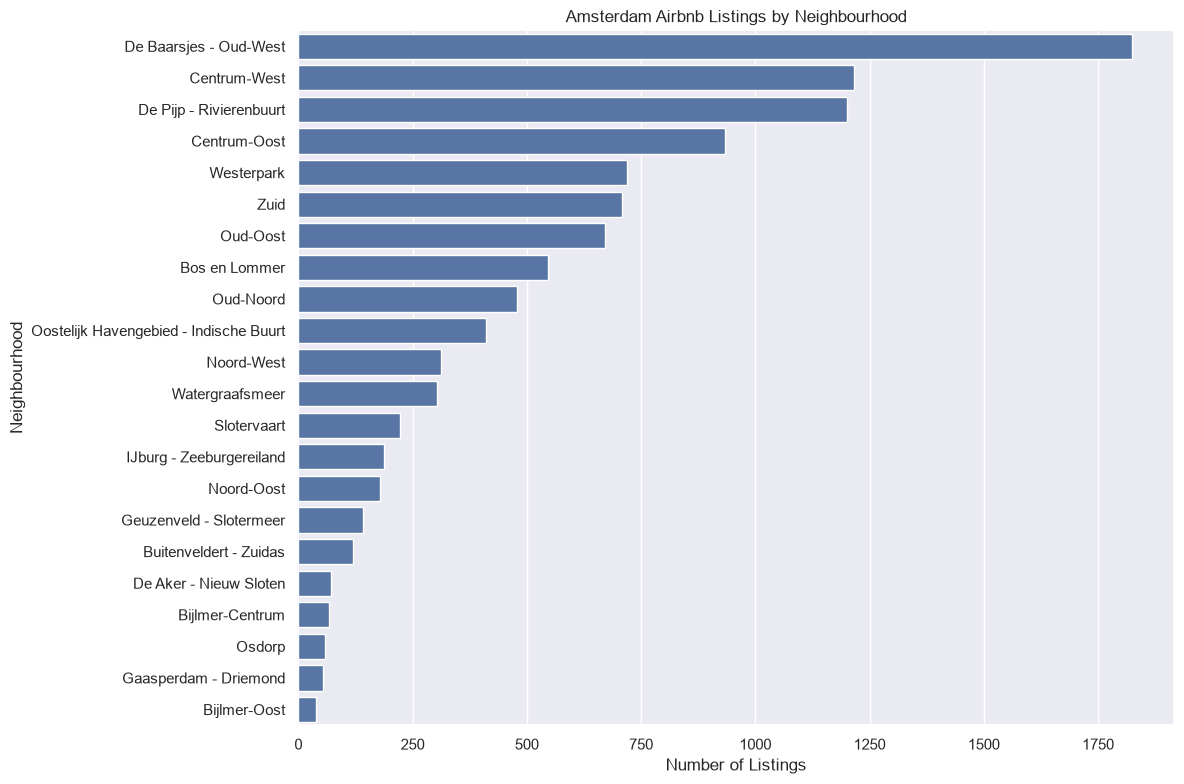

Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda\figures\01_listings_by_neighbourhood.png


In [86]:
neighbourhood_listing_counts.to_csv(
    TABLE_DIR / "neighbourhood_listing_counts.csv",
    index=False,
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=neighbourhood_listing_counts,
    x="listing_count",
    y="neighbourhood",
)
plt.title("Amsterdam Airbnb Listings by Neighbourhood")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")
plt.tight_layout()

path = FIGURE_DIR / "01_listings_by_neighbourhood.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


## 6. Price analysis by neighbourhood

In [87]:
neighbourhood_price = con.execute(
    '''
    SELECT
        neighbourhood,
        COUNT(*) AS total_listings,
        COUNT(price_best_available) AS listings_with_price,
        ROUND(AVG(price_best_available), 2) AS avg_price,
        ROUND(MEDIAN(price_best_available), 2) AS median_price,
        ROUND(QUANTILE_CONT(price_best_available, 0.25), 2) AS price_q1,
        ROUND(QUANTILE_CONT(price_best_available, 0.75), 2) AS price_q3
    FROM enriched_listing_master
    WHERE neighbourhood IS NOT NULL
    GROUP BY neighbourhood
    ORDER BY median_price DESC NULLS LAST
    '''
).fetchdf()

neighbourhood_price


,neighbourhood,total_listings,listings_with_price,avg_price,median_price,price_q1,price_q3
0,De Pijp - Rivierenbuurt,1201,702,380.7800,333.5000,235.5000,450.0000
1,De Baarsjes - Oud-West,1825,1073,364.6800,328.0000,239.0000,450.0000
2,Zuid,709,450,401.8500,327.0000,231.7500,481.2500
3,Centrum-West,1217,877,398.3600,290.0000,200.0000,460.0000
4,IJburg - Zeeburgereiland,187,116,330.7200,287.0000,182.2500,430.2500
5,Westerpark,720,405,332.5700,286.0000,229.0000,371.0000
6,Centrum-Oost,933,678,350.4100,282.5000,190.0000,448.0000
7,Watergraafsmeer,304,186,311.2400,280.0000,171.0000,381.0000
8,Oud-Oost,670,388,308.2400,276.0000,204.7500,372.5000
9,Noord-Oost,179,124,288.6500,266.5000,159.5000,351.2500


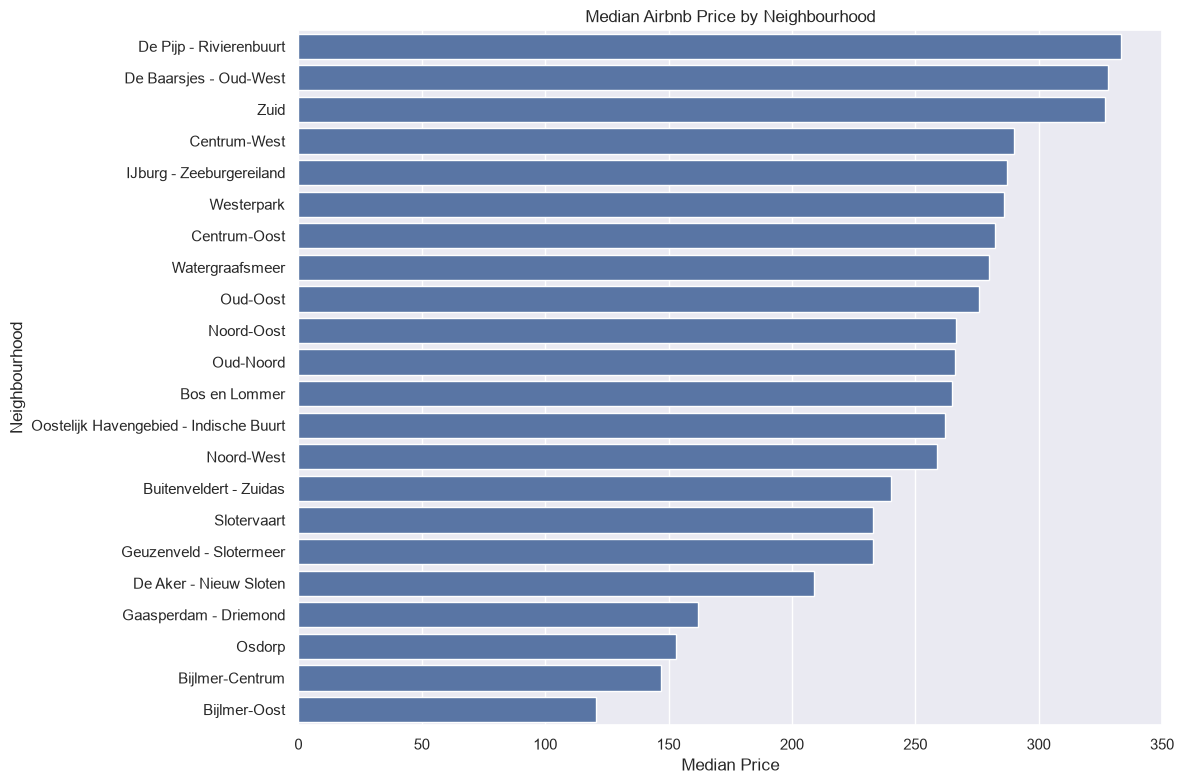

Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda\figures\02_median_price_by_neighbourhood.png


In [88]:
neighbourhood_price.to_csv(
    TABLE_DIR / "neighbourhood_price_summary.csv",
    index=False,
)

chart_data = (
    neighbourhood_price[
        neighbourhood_price["listings_with_price"] >= 20
    ]
    .sort_values("median_price", ascending=False)
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=chart_data,
    x="median_price",
    y="neighbourhood",
)
plt.title("Median Airbnb Price by Neighbourhood")
plt.xlabel("Median Price")
plt.ylabel("Neighbourhood")
plt.tight_layout()

path = FIGURE_DIR / "02_median_price_by_neighbourhood.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


## 7. Room type comparison

Median price is preferred over average price for comparison because price can be strongly right-skewed.


In [89]:
room_type_performance = con.execute(
    '''
    SELECT *
    FROM vw_room_type_performance
    ORDER BY listing_count DESC
    '''
).fetchdf()

room_type_performance


,room_type,listing_count,listings_with_price,avg_price,median_price,avg_review_score,total_review_events,avg_unavailability_rate_proxy
0,Entire home/apt,8489,4771,394.6200,331.0000,4.8700,221489,0.7867
1,Private room,1929,1653,203.6700,171.0000,4.7650,311510,0.5388
2,Hotel room,26,26,249.8500,227.5000,4.7750,6169,0.2436
3,Shared room,21,21,80.1000,52.0000,4.5160,5994,0.2231


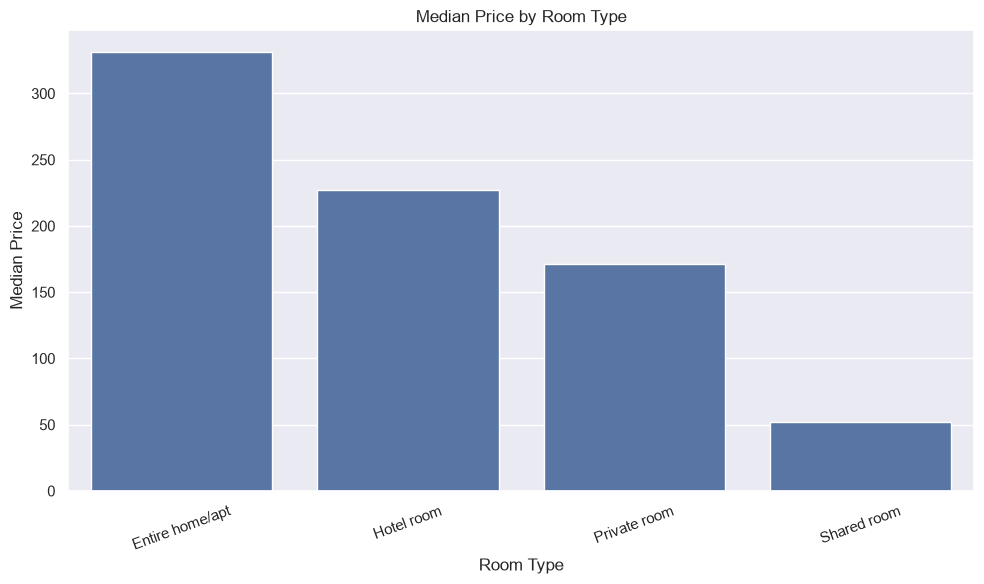

Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda\figures\03_median_price_by_room_type.png


In [90]:
room_type_performance.to_csv(
    TABLE_DIR / "room_type_performance.csv",
    index=False,
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=room_type_performance.sort_values("median_price", ascending=False),
    x="room_type",
    y="median_price",
)
plt.title("Median Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Median Price")
plt.xticks(rotation=20)
plt.tight_layout()

path = FIGURE_DIR / "03_median_price_by_room_type.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


## 8. Host portfolio analysis

In [91]:
host_portfolio_performance = con.execute(
    '''
    SELECT *
    FROM vw_host_portfolio_performance
    ORDER BY listing_count DESC
    '''
).fetchdf()

host_portfolio_performance


,host_portfolio_segment,listing_count,listings_with_price,avg_price,median_price,avg_review_score,avg_reviews_per_listing,avg_unavailability_rate_proxy
0,Single-listing host,8509,4811,371.1100,318.0000,4.8770,39.2900,0.7915
1,Small multi-listing host (2-5),1309,1059,274.8700,202.0000,4.7620,123.5000,0.5604
2,Large/professional host (6+),551,507,265.0700,200.0000,4.6350,72.8400,0.4302


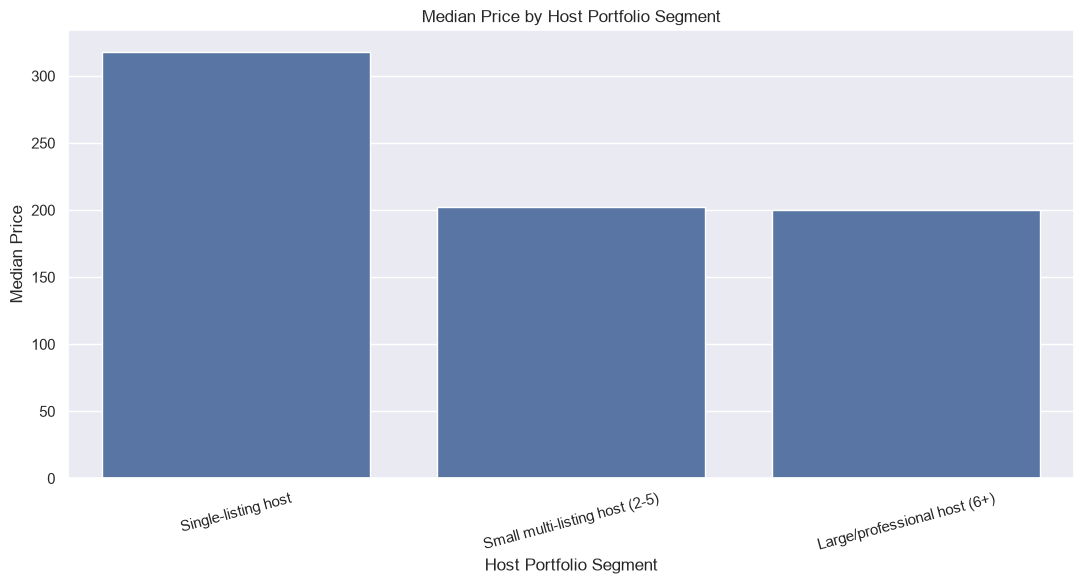

Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda\figures\04_median_price_by_host_segment.png


In [92]:
host_portfolio_performance.to_csv(
    TABLE_DIR / "host_portfolio_performance.csv",
    index=False,
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=host_portfolio_performance.sort_values("median_price", ascending=False),
    x="host_portfolio_segment",
    y="median_price",
)
plt.title("Median Price by Host Portfolio Segment")
plt.xlabel("Host Portfolio Segment")
plt.ylabel("Median Price")
plt.xticks(rotation=15)
plt.tight_layout()

path = FIGURE_DIR / "04_median_price_by_host_segment.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


## 9. Review activity by neighbourhood

Review activity is not equivalent to bookings.


In [93]:
review_activity_by_neighbourhood = con.execute(
    '''
    SELECT
        neighbourhood,
        COUNT(*) AS listing_count,
        SUM(detailed_review_count) AS total_review_events,
        ROUND(AVG(detailed_review_count), 2) AS avg_reviews_per_listing,
        ROUND(MEDIAN(detailed_review_count), 2) AS median_reviews_per_listing,
        SUM(CASE WHEN has_review_history THEN 1 ELSE 0 END) AS listings_with_reviews
    FROM enriched_listing_master
    WHERE neighbourhood IS NOT NULL
    GROUP BY neighbourhood
    ORDER BY total_review_events DESC
    '''
).fetchdf()

review_activity_by_neighbourhood


,neighbourhood,listing_count,total_review_events,avg_reviews_per_listing,median_reviews_per_listing,listings_with_reviews
0,Centrum-West,1217,"116,784.0000",95.9600,24.0000,"1,112.0000"
1,Centrum-Oost,933,"85,025.0000",91.1300,17.0000,839.0000
2,De Baarsjes - Oud-West,1825,"69,085.0000",37.8500,10.0000,"1,684.0000"
3,De Pijp - Rivierenbuurt,1201,"47,109.0000",39.2200,9.0000,"1,099.0000"
4,Zuid,709,"28,645.0000",40.4000,8.0000,620.0000
5,Westerpark,720,"27,910.0000",38.7600,11.0000,651.0000
6,Oud-Oost,670,"25,575.0000",38.1700,9.0000,598.0000
7,Oud-Noord,479,"25,295.0000",52.8100,8.0000,428.0000
8,Bos en Lommer,546,"17,223.0000",31.5400,8.0000,499.0000
9,Oostelijk Havengebied - Indische Buurt,411,"16,186.0000",39.3800,10.0000,377.0000


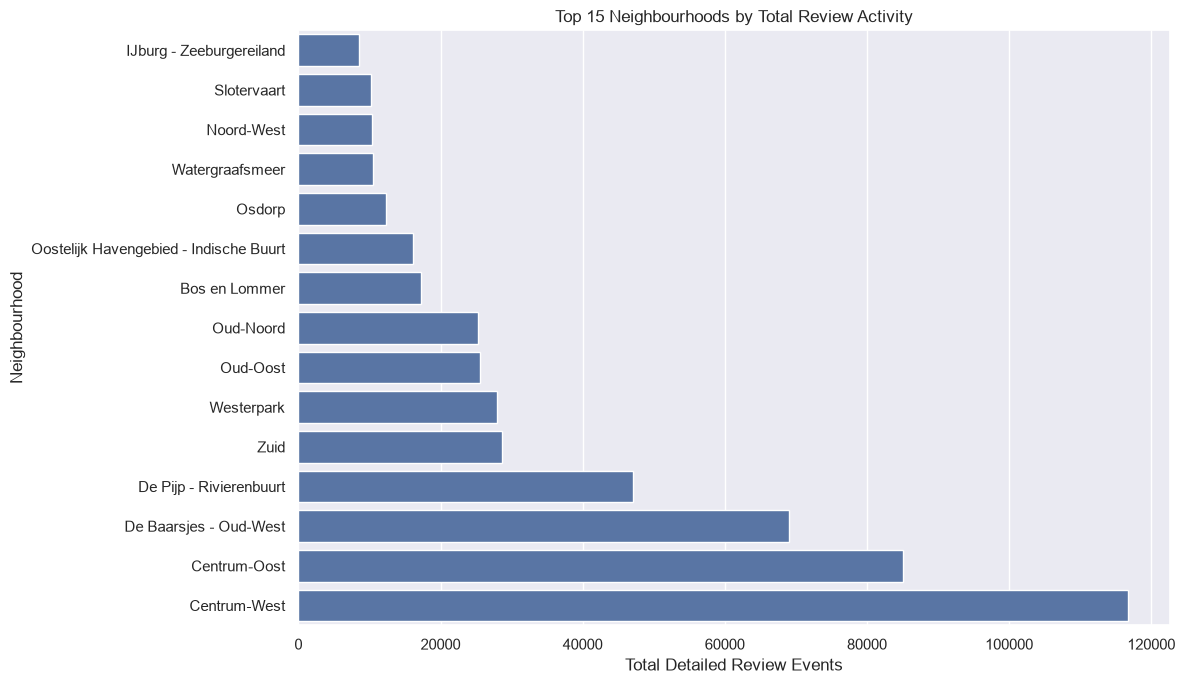

Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda\figures\05_review_activity_by_neighbourhood.png


In [94]:
review_activity_by_neighbourhood.to_csv(
    TABLE_DIR / "review_activity_by_neighbourhood.csv",
    index=False,
)

top_review_neighbourhoods = (
    review_activity_by_neighbourhood
    .head(15)
    .sort_values("total_review_events", ascending=True)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_review_neighbourhoods,
    x="total_review_events",
    y="neighbourhood",
)
plt.title("Top 15 Neighbourhoods by Total Review Activity")
plt.xlabel("Total Detailed Review Events")
plt.ylabel("Neighbourhood")
plt.tight_layout()

path = FIGURE_DIR / "05_review_activity_by_neighbourhood.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


## 10. Availability proxy by neighbourhood

The metric below is a calendar-based unavailability proxy, not true occupancy.


In [95]:
availability_by_neighbourhood = con.execute(
    '''
    SELECT
        neighbourhood,
        COUNT(*) AS listing_count,
        ROUND(AVG(availability_rate_observed), 4) AS avg_availability_rate,
        ROUND(AVG(unavailability_rate_proxy), 4) AS avg_unavailability_rate_proxy,
        ROUND(MEDIAN(unavailability_rate_proxy), 4) AS median_unavailability_rate_proxy
    FROM enriched_listing_master
    WHERE neighbourhood IS NOT NULL
    GROUP BY neighbourhood
    ORDER BY avg_unavailability_rate_proxy DESC
    '''
).fetchdf()

availability_by_neighbourhood


,neighbourhood,listing_count,avg_availability_rate,avg_unavailability_rate_proxy,median_unavailability_rate_proxy
0,Bos en Lommer,546,0.1675,0.8325,0.9918
1,Noord-West,312,0.2008,0.7992,0.9479
2,Oostelijk Havengebied - Indische Buurt,411,0.2123,0.7877,0.9616
3,Westerpark,720,0.2152,0.7848,0.9616
4,Bijlmer-Oost,39,0.2225,0.7775,0.9479
5,Oud-Noord,479,0.2248,0.7752,0.9589
6,De Baarsjes - Oud-West,1825,0.2261,0.7739,0.9562
7,Slotervaart,223,0.2283,0.7717,0.9726
8,IJburg - Zeeburgereiland,187,0.2342,0.7658,0.9233
9,Oud-Oost,670,0.2418,0.7582,0.9589


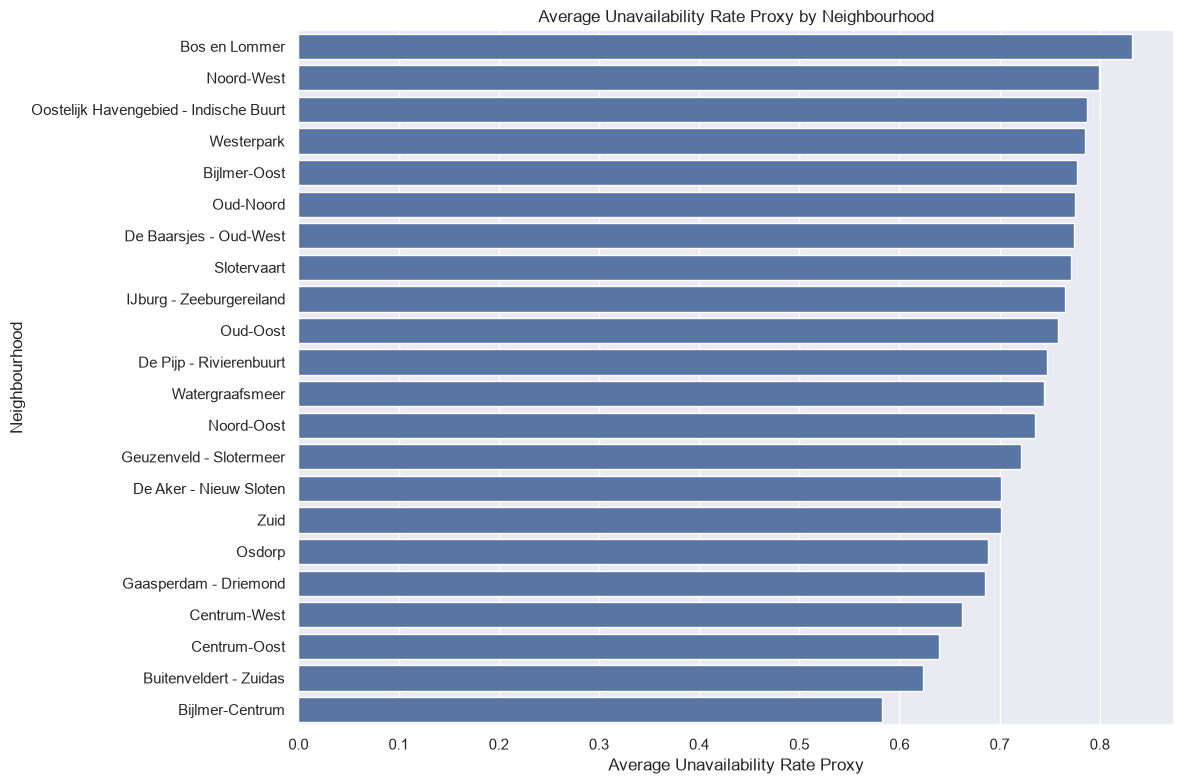

Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda\figures\06_unavailability_proxy_by_neighbourhood.png


In [96]:
availability_by_neighbourhood.to_csv(
    TABLE_DIR / "availability_proxy_by_neighbourhood.csv",
    index=False,
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=availability_by_neighbourhood,
    x="avg_unavailability_rate_proxy",
    y="neighbourhood",
)
plt.title("Average Unavailability Rate Proxy by Neighbourhood")
plt.xlabel("Average Unavailability Rate Proxy")
plt.ylabel("Neighbourhood")
plt.tight_layout()

path = FIGURE_DIR / "06_unavailability_proxy_by_neighbourhood.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


## 11. Price versus accommodation capacity

In [97]:
price_by_capacity = con.execute(
    '''
    SELECT
        accommodates,
        COUNT(*) AS total_listings,
        COUNT(price_best_available) AS listings_with_price,
        ROUND(AVG(price_best_available), 2) AS avg_price,
        ROUND(MEDIAN(price_best_available), 2) AS median_price
    FROM enriched_listing_master
    WHERE accommodates IS NOT NULL
      AND accommodates > 0
    GROUP BY accommodates
    ORDER BY accommodates
    '''
).fetchdf()

price_by_capacity


,accommodates,total_listings,listings_with_price,avg_price,median_price
0,1,164,124,115.1000,106.0000
1,2,5412,3221,265.0500,240.0000
2,3,840,514,302.1300,283.0000
3,4,3407,2116,445.9000,397.5000
4,5,237,156,462.7800,406.5000
5,6,209,165,558.5200,470.0000
6,7,26,19,"1,025.2600",906.0000
7,8,41,34,712.2400,461.5000
8,9,5,2,799.5000,799.5000
9,10,7,7,424.8600,387.0000


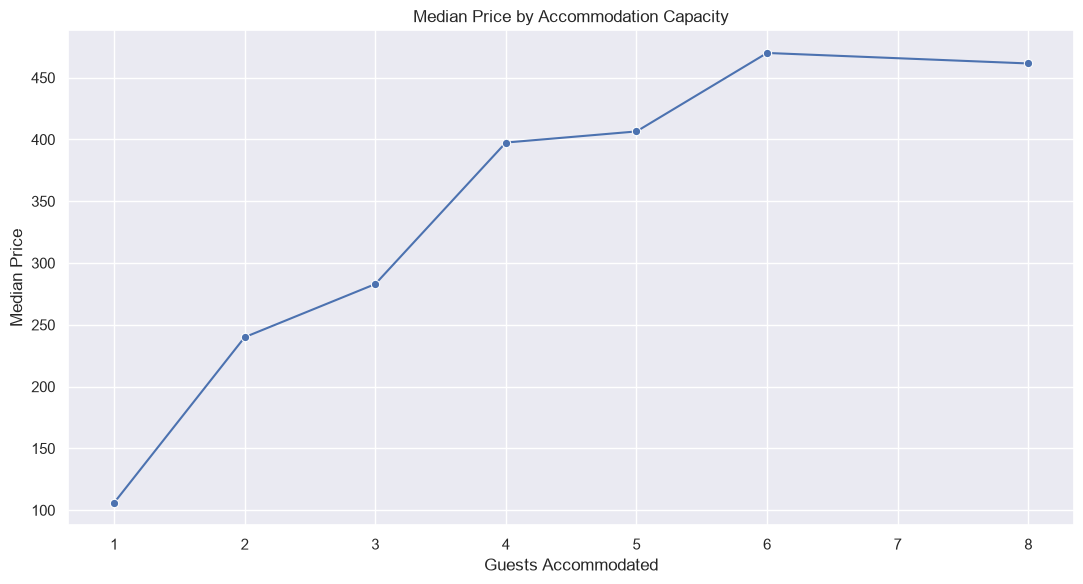

Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda\figures\07_median_price_by_capacity.png


In [98]:
price_by_capacity.to_csv(
    TABLE_DIR / "price_by_accommodation_capacity.csv",
    index=False,
)

chart_data = price_by_capacity[
    price_by_capacity["listings_with_price"] >= 20
]

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=chart_data,
    x="accommodates",
    y="median_price",
    marker="o",
)
plt.title("Median Price by Accommodation Capacity")
plt.xlabel("Guests Accommodated")
plt.ylabel("Median Price")
plt.tight_layout()

path = FIGURE_DIR / "07_median_price_by_capacity.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


## 12. Price distribution and IQR outliers

Outliers are flagged for awareness, not automatically deleted.


In [99]:
price_distribution = con.execute(
    '''
    SELECT
        COUNT(price_best_available) AS non_null_price_count,
        MIN(price_best_available) AS min_price,
        ROUND(QUANTILE_CONT(price_best_available, 0.25), 2) AS q1,
        ROUND(MEDIAN(price_best_available), 2) AS median_price,
        ROUND(QUANTILE_CONT(price_best_available, 0.75), 2) AS q3,
        MAX(price_best_available) AS max_price,
        ROUND(AVG(price_best_available), 2) AS avg_price
    FROM enriched_listing_master
    '''
).fetchdf()

price_distribution


,non_null_price_count,min_price,q1,median_price,q3,max_price,avg_price
0,6471,15.0000,205.0000,287.0000,410.0000,"11,412.0000",344.2400


In [100]:
q1 = float(price_distribution.loc[0, "q1"])
q3 = float(price_distribution.loc[0, "q3"])

iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

price_outlier_summary = con.execute(
    f'''
    SELECT
        COUNT(price_best_available) AS non_null_price_count,
        SUM(
            CASE
                WHEN price_best_available < {lower_bound}
                  OR price_best_available > {upper_bound}
                THEN 1
                ELSE 0
            END
        ) AS iqr_outlier_count,
        ROUND(
            100.0 * SUM(
                CASE
                    WHEN price_best_available < {lower_bound}
                      OR price_best_available > {upper_bound}
                    THEN 1
                    ELSE 0
                END
            )
            / NULLIF(COUNT(price_best_available), 0),
            2
        ) AS iqr_outlier_percentage
    FROM enriched_listing_master
    '''
).fetchdf()

print(f"Q1: {q1:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Lower bound: {lower_bound:,.2f}")
print(f"Upper bound: {upper_bound:,.2f}")

price_outlier_summary


Q1: 205.00
Q3: 410.00
IQR: 205.00
Lower bound: -102.50
Upper bound: 717.50


,non_null_price_count,iqr_outlier_count,iqr_outlier_percentage
0,6471,346.0000,5.3500


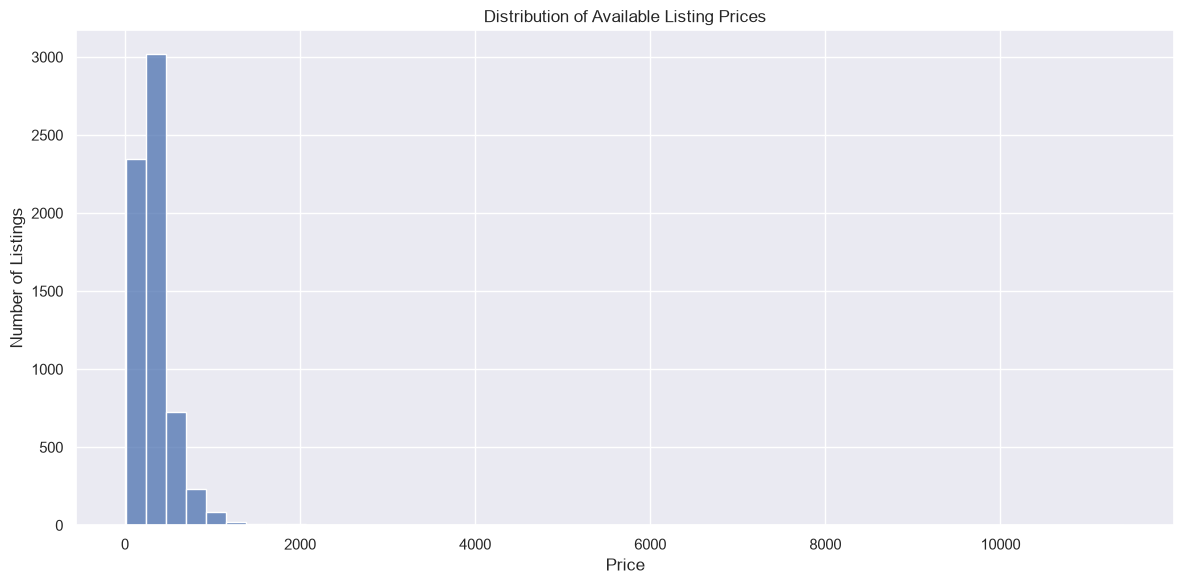

Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda\figures\08_price_distribution_full.png


In [101]:
price_values = con.execute(
    '''
    SELECT price_best_available
    FROM enriched_listing_master
    WHERE price_best_available IS NOT NULL
    '''
).fetchdf()

plt.figure(figsize=(12, 6))
sns.histplot(
    data=price_values,
    x="price_best_available",
    bins=50,
)
plt.title("Distribution of Available Listing Prices")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.tight_layout()

path = FIGURE_DIR / "08_price_distribution_full.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


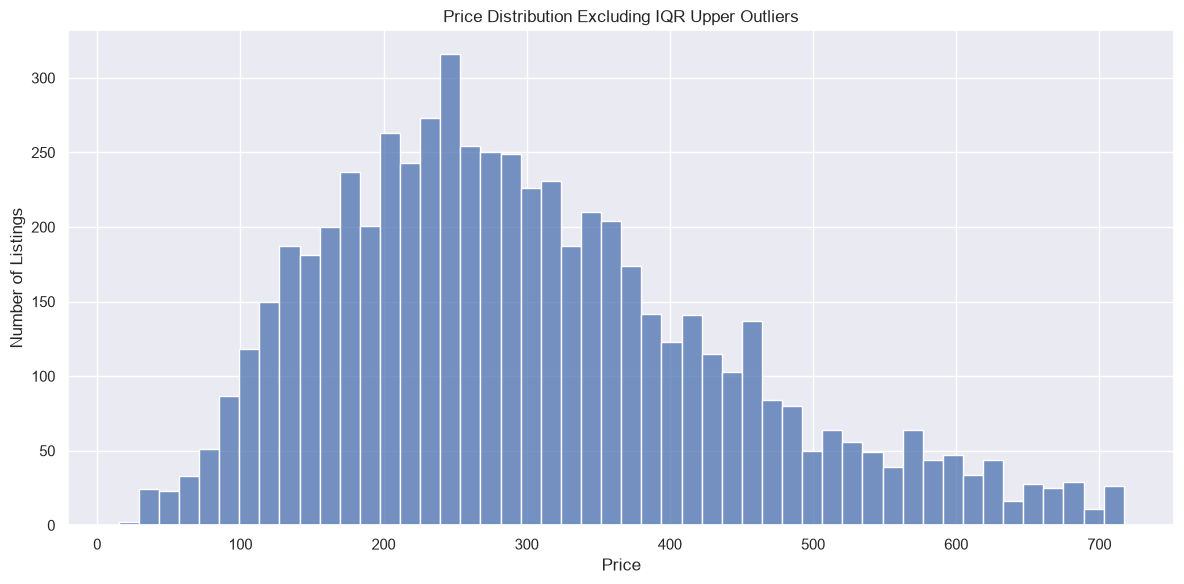

Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda\figures\09_price_distribution_without_iqr_upper_outliers.png


In [102]:
price_values_without_upper_outliers = price_values[
    price_values["price_best_available"] <= upper_bound
]

plt.figure(figsize=(12, 6))
sns.histplot(
    data=price_values_without_upper_outliers,
    x="price_best_available",
    bins=50,
)
plt.title("Price Distribution Excluding IQR Upper Outliers")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.tight_layout()

path = FIGURE_DIR / "09_price_distribution_without_iqr_upper_outliers.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


## 13. Correlation analysis

Correlation shows association, not causation.


In [103]:
candidate_columns = [
    "price_best_available",
    "accommodates",
    "bedrooms",
    "beds",
    "review_scores_rating",
    "detailed_review_count",
    "unavailability_rate_proxy",
    "host_portfolio_size",
]

available_columns = con.execute(
    '''
    SELECT column_name
    FROM information_schema.columns
    WHERE table_name = 'enriched_listing_master'
    '''
).fetchdf()["column_name"].tolist()

correlation_columns = [
    column
    for column in candidate_columns
    if column in available_columns
]

correlation_data = con.execute(
    f'''
    SELECT {", ".join(correlation_columns)}
    FROM enriched_listing_master
    '''
).fetchdf()

correlation_matrix = correlation_data.corr(numeric_only=True)
correlation_matrix


,price_best_available,accommodates,bedrooms,beds,review_scores_rating,detailed_review_count,unavailability_rate_proxy,host_portfolio_size
price_best_available,1.0000,0.3854,0.3811,0.3455,0.0610,-0.1415,-0.0561,-0.0975
accommodates,0.3854,1.0000,0.7368,0.7900,-0.0457,-0.0681,-0.0028,0.0052
bedrooms,0.3811,0.7368,1.0000,0.7258,0.0401,-0.0739,0.0596,-0.0822
beds,0.3455,0.7900,0.7258,1.0000,-0.0414,-0.0414,0.0363,0.0190
review_scores_rating,0.0610,-0.0457,0.0401,-0.0414,1.0000,-0.0529,0.1512,-0.2253
detailed_review_count,-0.1415,-0.0681,-0.0739,-0.0414,-0.0529,1.0000,-0.1741,0.0684
unavailability_rate_proxy,-0.0561,-0.0028,0.0596,0.0363,0.1512,-0.1741,1.0000,-0.2358
host_portfolio_size,-0.0975,0.0052,-0.0822,0.0190,-0.2253,0.0684,-0.2358,1.0000


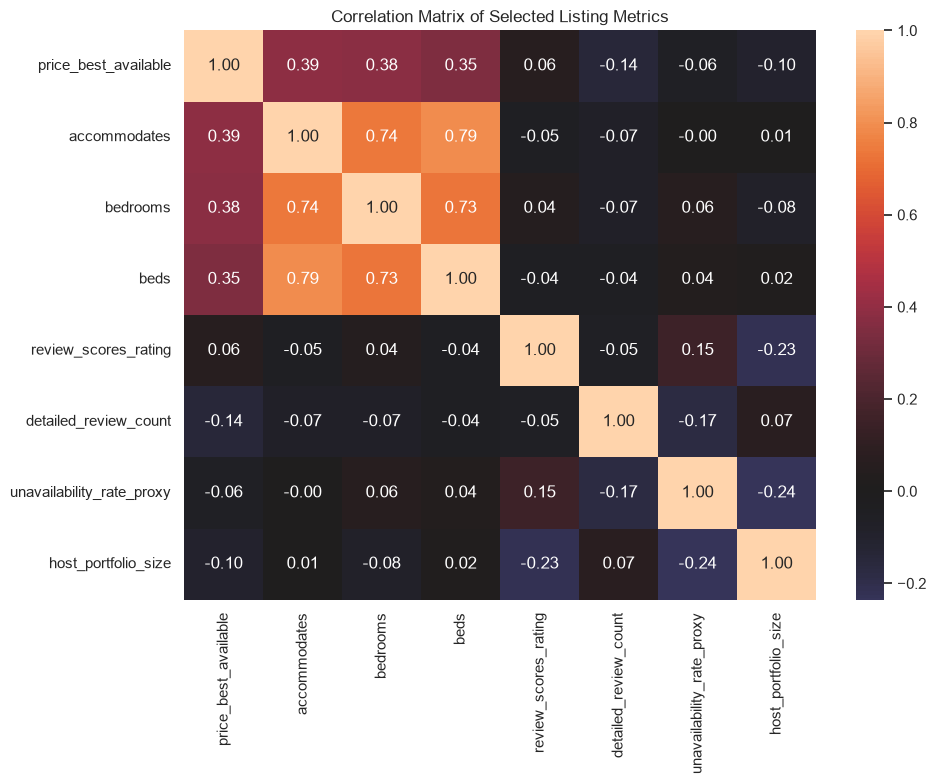

Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda\figures\10_correlation_matrix.png


In [104]:
correlation_matrix.to_csv(TABLE_DIR / "correlation_matrix.csv")

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
)
plt.title("Correlation Matrix of Selected Listing Metrics")
plt.tight_layout()

path = FIGURE_DIR / "10_correlation_matrix.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


## 14. Consolidated neighbourhood performance table

In [105]:
neighbourhood_performance = con.execute(
    '''
    SELECT *
    FROM vw_neighbourhood_performance
    ORDER BY listing_count DESC
    '''
).fetchdf()

neighbourhood_performance


,neighbourhood,listing_count,listings_with_price,avg_price,median_price,avg_review_score,total_review_events,avg_reviews_per_listing,avg_availability_rate,avg_unavailability_rate_proxy
0,De Baarsjes - Oud-West,1825,1073,364.6800,328.0000,4.8740,69085,37.8500,0.2261,0.7739
1,Centrum-West,1217,877,398.3600,290.0000,4.8150,116784,95.9600,0.3376,0.6624
2,De Pijp - Rivierenbuurt,1201,702,380.7800,333.5000,4.8560,47109,39.2200,0.2522,0.7478
3,Centrum-Oost,933,678,350.4100,282.5000,4.8090,85025,91.1300,0.3600,0.6400
4,Westerpark,720,405,332.5700,286.0000,4.8710,27910,38.7600,0.2152,0.7848
5,Zuid,709,450,401.8500,327.0000,4.8810,28645,40.4000,0.2984,0.7016
6,Oud-Oost,670,388,308.2400,276.0000,4.8560,25575,38.1700,0.2418,0.7582
7,Bos en Lommer,546,257,281.7900,265.0000,4.8660,17223,31.5400,0.1675,0.8325
8,Oud-Noord,479,283,357.0200,266.0000,4.8480,25295,52.8100,0.2248,0.7752
9,Oostelijk Havengebied - Indische Buurt,411,231,290.2400,262.0000,4.8620,16186,39.3800,0.2123,0.7877


In [106]:
neighbourhood_performance.to_csv(
    TABLE_DIR / "neighbourhood_performance.csv",
    index=False,
)

print("Saved:", TABLE_DIR / "neighbourhood_performance.csv")


Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\eda\tables\neighbourhood_performance.csv


## 15. Top and bottom neighbourhood snapshots

In [107]:
top_5_by_listing_count = (
    neighbourhood_performance
    .sort_values("listing_count", ascending=False)
    .head(5)
)

top_5_by_median_price = (
    neighbourhood_performance[
        neighbourhood_performance["listings_with_price"] >= 20
    ]
    .sort_values("median_price", ascending=False)
    .head(5)
)

bottom_5_by_median_price = (
    neighbourhood_performance[
        neighbourhood_performance["listings_with_price"] >= 20
    ]
    .sort_values("median_price", ascending=True)
    .head(5)
)

print("Top 5 neighbourhoods by listing count")
display(top_5_by_listing_count)

print("\nTop 5 neighbourhoods by median price")
display(top_5_by_median_price)

print("\nBottom 5 neighbourhoods by median price")
display(bottom_5_by_median_price)


Top 5 neighbourhoods by listing count


,neighbourhood,listing_count,listings_with_price,avg_price,median_price,avg_review_score,total_review_events,avg_reviews_per_listing,avg_availability_rate,avg_unavailability_rate_proxy
0,De Baarsjes - Oud-West,1825,1073,364.6800,328.0000,4.8740,69085,37.8500,0.2261,0.7739
1,Centrum-West,1217,877,398.3600,290.0000,4.8150,116784,95.9600,0.3376,0.6624
2,De Pijp - Rivierenbuurt,1201,702,380.7800,333.5000,4.8560,47109,39.2200,0.2522,0.7478
3,Centrum-Oost,933,678,350.4100,282.5000,4.8090,85025,91.1300,0.3600,0.6400
4,Westerpark,720,405,332.5700,286.0000,4.8710,27910,38.7600,0.2152,0.7848



Top 5 neighbourhoods by median price


,neighbourhood,listing_count,listings_with_price,avg_price,median_price,avg_review_score,total_review_events,avg_reviews_per_listing,avg_availability_rate,avg_unavailability_rate_proxy
2,De Pijp - Rivierenbuurt,1201,702,380.7800,333.5000,4.8560,47109,39.2200,0.2522,0.7478
0,De Baarsjes - Oud-West,1825,1073,364.6800,328.0000,4.8740,69085,37.8500,0.2261,0.7739
5,Zuid,709,450,401.8500,327.0000,4.8810,28645,40.4000,0.2984,0.7016
1,Centrum-West,1217,877,398.3600,290.0000,4.8150,116784,95.9600,0.3376,0.6624
13,IJburg - Zeeburgereiland,187,116,330.7200,287.0000,4.8530,8494,45.4200,0.2342,0.7658



Bottom 5 neighbourhoods by median price


,neighbourhood,listing_count,listings_with_price,avg_price,median_price,avg_review_score,total_review_events,avg_reviews_per_listing,avg_availability_rate,avg_unavailability_rate_proxy
21,Bijlmer-Oost,39,24,206.6700,120.5000,4.7880,1646,42.2100,0.2225,0.7775
18,Bijlmer-Centrum,66,51,184.2500,147.0000,4.7280,7121,107.8900,0.4175,0.5825
19,Osdorp,59,40,175.0500,153.0000,4.8280,12368,209.6300,0.3118,0.6882
20,Gaasperdam - Driemond,54,33,193.0600,162.0000,4.6950,3819,70.7200,0.3144,0.6856
17,De Aker - Nieuw Sloten,71,46,233.8900,209.0000,4.8550,4921,69.3100,0.2981,0.7019


## 16. Export compact EDA summary metrics

In [108]:
eda_summary_metrics = pd.DataFrame(
    {
        "metric": [
            "total_canonical_listings",
            "unique_listing_ids",
            "detailed_source_matches",
            "summary_only_listings_preserved",
            "listings_with_review_history",
            "listings_with_calendar_data",
            "listings_with_usable_price",
            "total_neighbourhoods",
            "total_detailed_review_events",
            "total_calendar_rows_represented",
        ],
        "value": [
            int(overall_summary.loc[0, "total_listings"]),
            int(overall_summary.loc[0, "unique_listing_ids"]),
            int(overall_summary.loc[0, "detailed_source_matches"]),
            int(overall_summary.loc[0, "summary_only_listings"]),
            int(overall_summary.loc[0, "listings_with_reviews"]),
            int(overall_summary.loc[0, "listings_with_calendar_data"]),
            int(overall_summary.loc[0, "listings_with_price"]),
            int(len(neighbourhood_listing_counts)),
            545162,
            3819725,
        ],
    }
)

eda_summary_metrics.to_csv(
    TABLE_DIR / "eda_summary_metrics.csv",
    index=False,
)

eda_summary_metrics


,metric,value
0,total_canonical_listings,10465
1,unique_listing_ids,10465
2,detailed_source_matches,10369
3,summary_only_listings_preserved,96
4,listings_with_review_history,9432
5,listings_with_calendar_data,10465
6,listings_with_usable_price,6471
7,total_neighbourhoods,22
8,total_detailed_review_events,545162
9,total_calendar_rows_represented,3819725


## 17. Final EDA checklist

After running all cells, verify:

- [ ] 10,465 canonical listings are preserved.
- [ ] Neighbourhood listing distribution analyzed.
- [ ] Neighbourhood median price analyzed.
- [ ] Room types compared.
- [ ] Host portfolio segments compared.
- [ ] Review activity analyzed.
- [ ] Calendar unavailability described only as a proxy.
- [ ] Price versus capacity explored.
- [ ] Price outliers flagged without blind deletion.
- [ ] Correlations interpreted as associations, not causation.
- [ ] Report-ready tables exported.
- [ ] Report-ready figures exported.


## 18. Final interpretation notes

After execution, summarize findings under these headings:

### Finding 1 — Supply concentration
Which neighbourhoods have the most listings?

### Finding 2 — Price differences
Which neighbourhoods and room types have the highest and lowest median prices?

### Finding 3 — Host portfolio patterns
How do single-listing, small multi-listing, and large/professional hosts differ?

### Finding 4 — Review activity
Which neighbourhoods have the strongest observed review activity?

### Finding 5 — Calendar availability patterns
Which neighbourhoods show higher or lower unavailability proxies?

### Finding 6 — Price and capacity
Does median price generally increase with accommodation capacity?

### Finding 7 — Outliers
How skewed is the price distribution, and how many IQR outliers exist?

### Finding 8 — Correlations
Which numeric relationships are strongest and useful for Phase 9 hypotheses?


# Part B — Statistical Analysis

This section tests two focused statistical hypotheses using the validated and enriched Amsterdam Airbnb listing dataset.

## Statistical significance level

For both hypotheses:

- Significance level: α = 0.05
- If p-value < 0.05, reject the null hypothesis.
- If p-value ≥ 0.05, fail to reject the null hypothesis.

Because the EDA showed skewed price distributions, outliers, and bounded review-score variables, the Mann–Whitney U test is used as a robust non-parametric comparison between two independent groups.

The analysis reports:

- Sample size
- Median
- Interquartile range
- Mann–Whitney U statistic
- p-value
- Rank-biserial effect size
- Statistical conclusion
- Business interpretation

> Statistical significance does not necessarily imply practical or business significance. Effect size and descriptive statistics must also be considered.

## Hypothesis 1 — Do prices differ between entire homes and private rooms?

### Business question

Do `Entire home/apt` listings have different price distributions from `Private room` listings?

### Null hypothesis H₀

There is no statistically significant difference in the price distributions of entire homes/apartments and private rooms.

### Alternative hypothesis H₁

There is a statistically significant difference in the price distributions of entire homes/apartments and private rooms.

### Test selected

**Mann–Whitney U test, two-sided**

This non-parametric test is appropriate because:

- The two groups are independent.
- Price is strongly right-skewed.
- The dataset contains extreme price values.
- Normality cannot reasonably be assumed.

#### import statistics library and create folders

In [109]:
from scipy.stats import mannwhitneyu

STATISTICS_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "statistics"
STATISTICS_FIGURE_DIR = STATISTICS_OUTPUT_DIR / "figures"
STATISTICS_TABLE_DIR = STATISTICS_OUTPUT_DIR / "tables"

STATISTICS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
STATISTICS_TABLE_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.05

print("Statistics output directory:", STATISTICS_OUTPUT_DIR)
print("Significance level:", ALPHA)

Statistics output directory: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\statistics
Significance level: 0.05


#### prepare Hypothesis 1 data

In [110]:
hypothesis_1_data = con.execute(
    '''
    SELECT
        room_type,
        price_best_available
    FROM enriched_listing_master
    WHERE price_best_available IS NOT NULL
      AND room_type IN (
          'Entire home/apt',
          'Private room'
      )
    '''
).fetchdf()

print("Shape:", hypothesis_1_data.shape)
print()
print(hypothesis_1_data.groupby("room_type").size())

Shape: (6424, 2)

room_type
Entire home/apt    4771
Private room       1653
dtype: int64


#### descriptive statistics

In [111]:
hypothesis_1_summary = (
    hypothesis_1_data
    .groupby("room_type")["price_best_available"]
    .agg(
        sample_size="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

hypothesis_1_summary["iqr"] = (
    hypothesis_1_summary["q3"]
    - hypothesis_1_summary["q1"]
)

hypothesis_1_summary

,room_type,sample_size,mean,median,std,minimum,maximum,q1,q3,iqr
0,Entire home/apt,4771,394.6231,331.0000,357.1093,26.0000,"11,412.0000",252.0000,451.0000,199.0000
1,Private room,1653,203.6667,171.0000,139.4022,15.0000,"1,712.0000",129.0000,229.0000,100.0000


#### perform Mann–Whitney U test

In [112]:
entire_home_prices = hypothesis_1_data.loc[
    hypothesis_1_data["room_type"] == "Entire home/apt",
    "price_best_available",
].dropna()

private_room_prices = hypothesis_1_data.loc[
    hypothesis_1_data["room_type"] == "Private room",
    "price_best_available",
].dropna()

u_statistic_h1, p_value_h1 = mannwhitneyu(
    entire_home_prices,
    private_room_prices,
    alternative="two-sided",
)

n_entire = len(entire_home_prices)
n_private = len(private_room_prices)

rank_biserial_h1 = (
    (2 * u_statistic_h1)
    / (n_entire * n_private)
    - 1
)

print("Hypothesis 1 Results")
print("-" * 60)
print(f"Entire home sample size: {n_entire:,}")
print(f"Private room sample size: {n_private:,}")
print()
print(f"Entire home median price: {entire_home_prices.median():,.2f}")
print(f"Private room median price: {private_room_prices.median():,.2f}")
print()
print(f"Mann–Whitney U statistic: {u_statistic_h1:,.4f}")
print(f"P-value: {p_value_h1:.10g}")
print(f"Rank-biserial effect size: {rank_biserial_h1:.4f}")

Hypothesis 1 Results
------------------------------------------------------------
Entire home sample size: 4,771
Private room sample size: 1,653

Entire home median price: 331.00
Private room median price: 171.00

Mann–Whitney U statistic: 6,692,891.0000
P-value: 0
Rank-biserial effect size: 0.6973


#### conclusion

In [113]:
if p_value_h1 < ALPHA:
    hypothesis_1_decision = "Reject H0"
    hypothesis_1_conclusion = (
        "There is statistically significant evidence that the price "
        "distributions of entire homes/apartments and private rooms differ."
    )
else:
    hypothesis_1_decision = "Fail to reject H0"
    hypothesis_1_conclusion = (
        "There is insufficient statistical evidence to conclude that the "
        "price distributions of entire homes/apartments and private rooms differ."
    )

print("Decision:", hypothesis_1_decision)
print()
print("Conclusion:")
print(hypothesis_1_conclusion)

Decision: Reject H0

Conclusion:
There is statistically significant evidence that the price distributions of entire homes/apartments and private rooms differ.


#### visualization

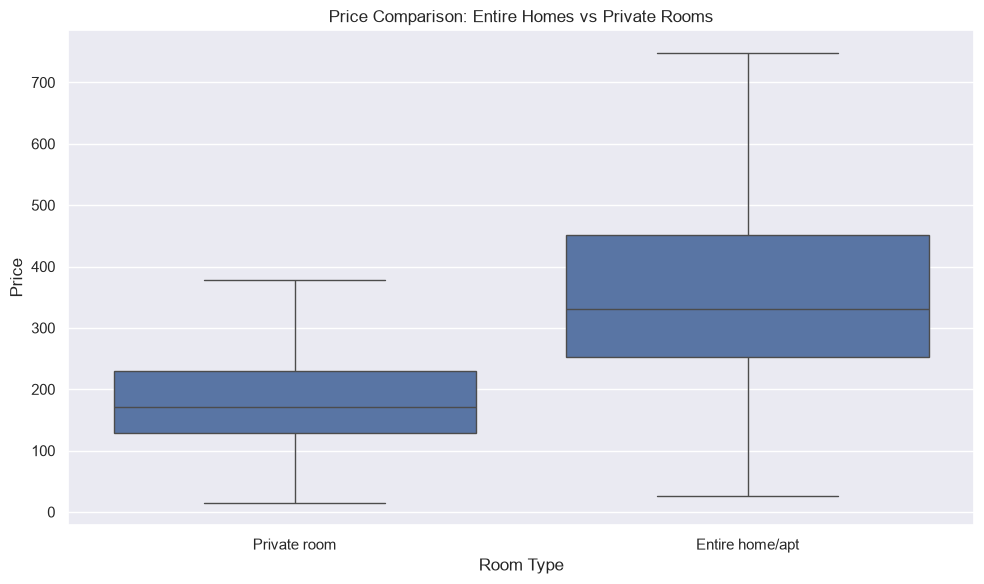

Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\statistics\figures\01_hypothesis_entire_home_vs_private_room_price.png


In [114]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hypothesis_1_data,
    x="room_type",
    y="price_best_available",
    showfliers=False,
)

plt.title("Price Comparison: Entire Homes vs Private Rooms")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.tight_layout()

path = (
    STATISTICS_FIGURE_DIR
    / "01_hypothesis_entire_home_vs_private_room_price.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", path)

### Hypothesis 1 Interpretation

The Mann–Whitney U test identified a statistically significant difference in the price distributions of entire homes/apartments and private rooms.

Entire homes/apartments had a median price of **331**, compared with **171** for private rooms. The Mann–Whitney U statistic was **6,692,891**, with a p-value far below the 0.05 significance threshold. Therefore, the null hypothesis was rejected.

The rank-biserial effect size was **0.6973**, indicating a substantial difference between the two groups. The observed difference is therefore not only statistically significant but also practically meaningful.

**Finding:** Entire homes/apartments are generally priced considerably higher than private rooms in the Amsterdam Airbnb dataset.

**Business meaning:** Room type is strongly associated with listing price. Entire homes provide exclusive use of the property and typically offer more space and privacy, which is consistent with their substantially higher observed prices.

**Recommended action:** Pricing comparisons and benchmarking should be performed within comparable room-type segments rather than across the entire market, because combining entire homes and private rooms could hide important structural price differences.

## Hypothesis 2 — Do superhosts and non-superhosts differ in review scores?

### Business question

Do listings managed by superhosts have different review-score distributions from listings managed by non-superhosts?

### Null hypothesis H₀

There is no statistically significant difference in review-score distributions between superhost and non-superhost listings.

### Alternative hypothesis H₁

There is a statistically significant difference in review-score distributions between superhost and non-superhost listings.

### Test selected

**Mann–Whitney U test, two-sided**

This is appropriate because:

- The two host groups are independent.
- Review scores are bounded.
- Review scores may be skewed and concentrated near high values.
- Normality should not be assumed.

#### prepare Hypothesis 2 data

In [115]:
hypothesis_2_data = con.execute(
    '''
    SELECT
        host_is_superhost,
        review_scores_rating
    FROM enriched_listing_master
    WHERE host_is_superhost IS NOT NULL
      AND review_scores_rating IS NOT NULL
    '''
).fetchdf()

hypothesis_2_data["host_group"] = (
    hypothesis_2_data["host_is_superhost"]
    .map(
        {
            True: "Superhost",
            False: "Non-superhost",
        }
    )
)

print("Shape:", hypothesis_2_data.shape)
print()
print(hypothesis_2_data.groupby("host_group").size())

Shape: (9227, 3)

host_group
Non-superhost    7566
Superhost        1661
dtype: int64


#### descriptive statistics

In [116]:
hypothesis_2_summary = (
    hypothesis_2_data
    .groupby("host_group")["review_scores_rating"]
    .agg(
        sample_size="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

hypothesis_2_summary["iqr"] = (
    hypothesis_2_summary["q3"]
    - hypothesis_2_summary["q1"]
)

hypothesis_2_summary

,host_group,sample_size,mean,median,std,minimum,maximum,q1,q3,iqr
0,Non-superhost,7566,4.8503,4.9400,0.2554,1.0000,5.0000,4.7900,5.0000,0.2100
1,Superhost,1661,4.8640,4.9000,0.1558,3.3300,5.0000,4.8200,4.9600,0.1400


#### perform Mann–Whitney U test

In [117]:
superhost_scores = hypothesis_2_data.loc[
    hypothesis_2_data["host_group"] == "Superhost",
    "review_scores_rating",
].dropna()

non_superhost_scores = hypothesis_2_data.loc[
    hypothesis_2_data["host_group"] == "Non-superhost",
    "review_scores_rating",
].dropna()

u_statistic_h2, p_value_h2 = mannwhitneyu(
    superhost_scores,
    non_superhost_scores,
    alternative="two-sided",
)

n_superhost = len(superhost_scores)
n_non_superhost = len(non_superhost_scores)

rank_biserial_h2 = (
    (2 * u_statistic_h2)
    / (n_superhost * n_non_superhost)
    - 1
)

print("Hypothesis 2 Results")
print("-" * 60)
print(f"Superhost sample size: {n_superhost:,}")
print(f"Non-superhost sample size: {n_non_superhost:,}")
print()
print(f"Superhost median score: {superhost_scores.median():,.4f}")
print(f"Non-superhost median score: {non_superhost_scores.median():,.4f}")
print()
print(f"Mann–Whitney U statistic: {u_statistic_h2:,.4f}")
print(f"P-value: {p_value_h2:.10g}")
print(f"Rank-biserial effect size: {rank_biserial_h2:.4f}")

Hypothesis 2 Results
------------------------------------------------------------
Superhost sample size: 1,661
Non-superhost sample size: 7,566

Superhost median score: 4.9000
Non-superhost median score: 4.9400

Mann–Whitney U statistic: 5,293,896.5000
P-value: 3.192973009e-25
Rank-biserial effect size: -0.1575


#### conclusion

In [118]:
if p_value_h2 < ALPHA:
    hypothesis_2_decision = "Reject H0"
    hypothesis_2_conclusion = (
        "There is statistically significant evidence that review-score "
        "distributions differ between superhost and non-superhost listings."
    )
else:
    hypothesis_2_decision = "Fail to reject H0"
    hypothesis_2_conclusion = (
        "There is insufficient statistical evidence to conclude that review-score "
        "distributions differ between superhost and non-superhost listings."
    )

print("Decision:", hypothesis_2_decision)
print()
print("Conclusion:")
print(hypothesis_2_conclusion)

Decision: Reject H0

Conclusion:
There is statistically significant evidence that review-score distributions differ between superhost and non-superhost listings.


#### visualization

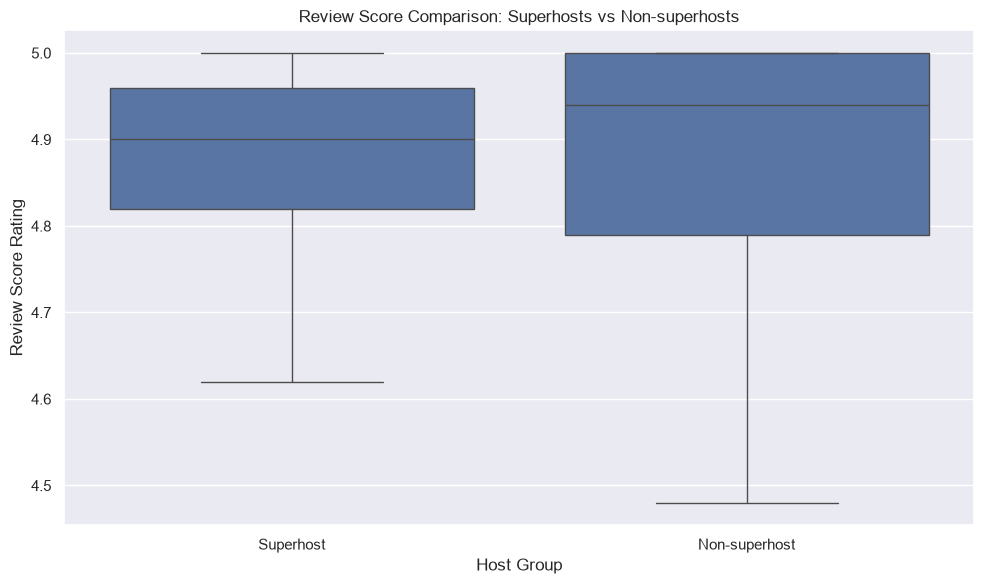

Saved: C:\Users\saths\Desktop\MyProjects\Expernetic Data Challenge\airbnb-data-challenge\outputs\statistics\figures\02_hypothesis_superhost_vs_non_superhost_scores.png


In [119]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hypothesis_2_data,
    x="host_group",
    y="review_scores_rating",
    showfliers=False,
)

plt.title("Review Score Comparison: Superhosts vs Non-superhosts")
plt.xlabel("Host Group")
plt.ylabel("Review Score Rating")
plt.tight_layout()

path = (
    STATISTICS_FIGURE_DIR
    / "02_hypothesis_superhost_vs_non_superhost_scores.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", path)

### Hypothesis 2 Interpretation

The Mann–Whitney U test identified a statistically significant difference in review-score distributions between superhost and non-superhost listings.

Superhost listings had a mean review score of **4.8640** and a median of **4.9000**, while non-superhost listings had a mean of **4.8503** and a median of **4.9400**. The Mann–Whitney U statistic was **5,293,896.5**, with a p-value of approximately **3.19 × 10⁻²⁵**, which is far below the 0.05 significance threshold. Therefore, the null hypothesis was rejected.

However, the rank-biserial effect size was only **-0.1575**, indicating that the practical difference between the two distributions is relatively small. The descriptive statistics also show a nuanced pattern: superhosts had a slightly higher mean score, while non-superhosts had a slightly higher median score. Superhost scores were also more tightly concentrated, with a smaller interquartile range.

**Finding:** Superhost and non-superhost listings have statistically different review-score distributions, but the practical magnitude of this difference is relatively small.

**Business meaning:** Superhost status is associated with review-score patterns, but it should not be treated as a simple guarantee of higher ratings. The substantial overlap between the two groups suggests that other factors may also influence review scores.

**Recommended action:** Superhost status may be considered alongside other factors such as room type, neighbourhood, listing characteristics, cleanliness, communication, and review history when evaluating listing quality or performance.

#### Final Statistical Results Summary

In [120]:
statistical_test_results = pd.DataFrame(
    [
        {
            "hypothesis": "H1",
            "business_question": (
                "Do prices differ between entire homes/apartments "
                "and private rooms?"
            ),
            "test": "Mann-Whitney U",
            "group_1": "Entire home/apt",
            "group_1_n": n_entire,
            "group_1_median": entire_home_prices.median(),
            "group_2": "Private room",
            "group_2_n": n_private,
            "group_2_median": private_room_prices.median(),
            "test_statistic": u_statistic_h1,
            "p_value": p_value_h1,
            "effect_size_rank_biserial": rank_biserial_h1,
            "alpha": ALPHA,
            "decision": hypothesis_1_decision,
            "conclusion": hypothesis_1_conclusion,
        },
        {
            "hypothesis": "H2",
            "business_question": (
                "Do review scores differ between superhost "
                "and non-superhost listings?"
            ),
            "test": "Mann-Whitney U",
            "group_1": "Superhost",
            "group_1_n": n_superhost,
            "group_1_median": superhost_scores.median(),
            "group_2": "Non-superhost",
            "group_2_n": n_non_superhost,
            "group_2_median": non_superhost_scores.median(),
            "test_statistic": u_statistic_h2,
            "p_value": p_value_h2,
            "effect_size_rank_biserial": rank_biserial_h2,
            "alpha": ALPHA,
            "decision": hypothesis_2_decision,
            "conclusion": hypothesis_2_conclusion,
        },
    ]
)

statistical_test_results.to_csv(
    STATISTICS_TABLE_DIR / "statistical_test_results.csv",
    index=False,
)

hypothesis_1_summary.to_csv(
    STATISTICS_TABLE_DIR / "hypothesis_1_descriptive_summary.csv",
    index=False,
)

hypothesis_2_summary.to_csv(
    STATISTICS_TABLE_DIR / "hypothesis_2_descriptive_summary.csv",
    index=False,
)

statistical_test_results

,hypothesis,business_question,test,group_1,group_1_n,group_1_median,group_2,group_2_n,group_2_median,test_statistic,p_value,effect_size_rank_biserial,alpha,decision,conclusion
0,H1,Do prices differ between entire homes/apartmen...,Mann-Whitney U,Entire home/apt,4771,331.0000,Private room,1653,171.0000,"6,692,891.0000",0.0000,0.6973,0.0500,Reject H0,There is statistically significant evidence th...
1,H2,Do review scores differ between superhost and ...,Mann-Whitney U,Superhost,1661,4.9000,Non-superhost,7566,4.9400,"5,293,896.5000",0.0000,-0.1575,0.0500,Reject H0,There is statistically significant evidence th...


In [121]:
statistical_test_results_display = statistical_test_results.copy()

statistical_test_results_display["p_value_formatted"] = (
    statistical_test_results_display["p_value"]
    .apply(
        lambda p: "< 0.001"
        if p < 0.001
        else f"{p:.4f}"
    )
)

statistical_test_results_display[
    [
        "hypothesis",
        "test",
        "group_1",
        "group_1_n",
        "group_1_median",
        "group_2",
        "group_2_n",
        "group_2_median",
        "test_statistic",
        "p_value_formatted",
        "effect_size_rank_biserial",
        "decision",
    ]
]

,hypothesis,test,group_1,group_1_n,group_1_median,group_2,group_2_n,group_2_median,test_statistic,p_value_formatted,effect_size_rank_biserial,decision
0,H1,Mann-Whitney U,Entire home/apt,4771,331.0000,Private room,1653,171.0000,"6,692,891.0000",< 0.001,0.6973,Reject H0
1,H2,Mann-Whitney U,Superhost,1661,4.9000,Non-superhost,7566,4.9400,"5,293,896.5000",< 0.001,-0.1575,Reject H0


In [122]:
statistical_test_results.to_csv(
    STATISTICS_TABLE_DIR / "statistical_test_results.csv",
    index=False,
)

hypothesis_1_summary.to_csv(
    STATISTICS_TABLE_DIR / "hypothesis_1_descriptive_summary.csv",
    index=False,
)

hypothesis_2_summary.to_csv(
    STATISTICS_TABLE_DIR / "hypothesis_2_descriptive_summary.csv",
    index=False,
)

print("Saved statistical_test_results.csv")
print("Saved hypothesis_1_descriptive_summary.csv")
print("Saved hypothesis_2_descriptive_summary.csv")

Saved statistical_test_results.csv
Saved hypothesis_1_descriptive_summary.csv
Saved hypothesis_2_descriptive_summary.csv


## Final Overall Statistical Takeaway

The statistical analysis produced two clearly different types of findings.

### Hypothesis 1 — Entire homes vs private rooms

The comparison between entire homes/apartments and private rooms showed a statistically significant and practically substantial difference in price distributions.

Entire homes/apartments had a median price of **331**, compared with **171** for private rooms. The Mann–Whitney U test produced a p-value far below the 0.05 significance level, so the null hypothesis was rejected.

The rank-biserial effect size was **0.6973**, indicating a strong practical difference between the two room-type groups.

This result suggests that room type is strongly associated with listing price, and pricing analysis should therefore compare similar room categories rather than combining all listings into a single market benchmark.

---

### Hypothesis 2 — Superhosts vs non-superhosts

The comparison between superhost and non-superhost listings also showed a statistically significant difference in review-score distributions.

Superhosts had a mean review score of **4.8640** and a median of **4.9000**, while non-superhosts had a mean of **4.8503** and a median of **4.9400**.

The Mann–Whitney U test produced a p-value of approximately **3.19 × 10⁻²⁵**, so the null hypothesis was rejected.

However, the rank-biserial effect size was only **-0.1575**, indicating that the practical difference between the two groups is relatively small.

This means that although superhost status is statistically associated with review-score patterns, it should not be treated as a simple guarantee of higher ratings. Other factors such as room type, neighbourhood, cleanliness, communication, listing characteristics, and review history may also contribute to review outcomes.

---

### Overall conclusion

The two hypotheses demonstrate an important statistical lesson:

> **Statistical significance does not necessarily mean practical importance.**

For Hypothesis 1, both the statistical evidence and the effect size were strong, showing a meaningful difference between entire-home and private-room prices.

For Hypothesis 2, the result was statistically significant, but the effect size was much smaller, meaning that the practical difference between superhost and non-superhost review-score distributions was limited.

Therefore, p-values should always be interpreted together with:

- Descriptive statistics
- Median and interquartile range
- Effect size
- Sample size
- Business context

These findings provide a stronger basis for business interpretation and help avoid overclaiming results based only on statistical significance.

In [123]:
con.close()
print("DuckDB connection closed.")

DuckDB connection closed.
